# Exploratory Data Analysis — Bank Customer Churn

Before building any model, we need to understand the data: what the distributions look like, how severe the class imbalance is, which features correlate with churn, and whether there are any data quality issues.

All findings here informed the preprocessing and modeling decisions in `src/`.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.data.preprocess import clean_data, encode_features

plt.style.use('seaborn-v0_8-darkgrid')
pal = ['#4C72B0', '#DD8452']

df_raw = pd.read_csv('../data/raw/churn.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15259482,Customer_0,545,France,Male,29,4,0.0,2,1,1,190797.21,0
1,2,15420936,Customer_1,757,Spain,Male,43,5,0.0,2,0,1,26063.69,0
2,3,15783196,Customer_2,839,Germany,Male,51,10,0.0,2,1,1,174923.16,0
3,4,15847815,Customer_3,578,Germany,Female,25,4,0.0,1,0,1,87848.39,0
4,5,15488949,Customer_4,613,France,Male,55,8,0.0,2,0,1,194995.57,0


## 1. Data Quality

In [2]:
print('Missing values:')
print(df_raw.isnull().sum())
print(f'\nDuplicates: {df_raw.duplicated().sum()}')
print('\nData types:')
print(df_raw.dtypes)
print('\nBasic stats:')
df_raw.describe().round(2)

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0

Data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Basic stats:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,15497611.09,648.76,37.61,5.02,57112.60,1.55,0.71,0.51,100346.21,0.09
std,2886.90,286301.68,96.02,9.69,3.14,59899.48,0.61,0.45,0.50,57696.89,0.29
min,1.00,15000077.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,56.78,0.00
25%,2500.75,15250506.50,582.00,31.00,2.00,0.00,1.00,0.00,0.00,50105.36,0.00
50%,5000.50,15496143.00,650.00,38.00,5.00,43559.16,1.00,1.00,1.00,101017.46,0.00
75%,7500.25,15744504.75,715.00,44.00,8.00,101653.76,2.00,1.00,1.00,149646.71,0.00
max,10000.00,15999758.00,850.00,82.00,10.00,287122.73,4.00,1.00,1.00,199982.40,1.00


## 2. Class Imbalance

Churn prediction is a classic imbalanced classification problem. Understanding the ratio upfront determines whether we need resampling (SMOTE) or class weighting.

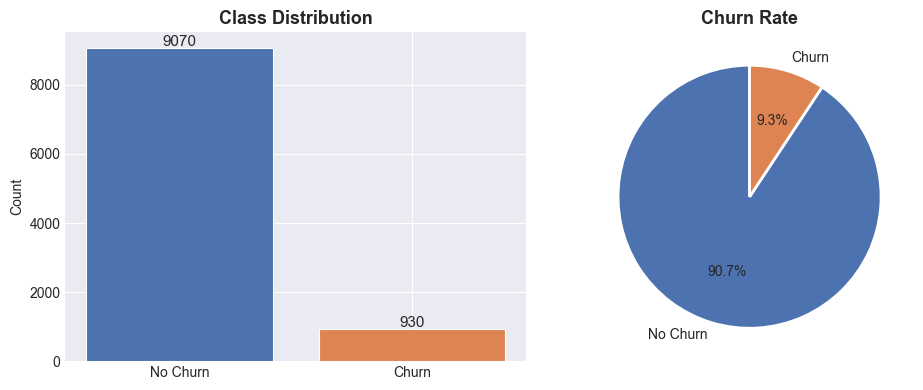

Churn rate: 9.30%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df_raw['Exited'].value_counts()
labels = ['No Churn', 'Churn']
axes[0].bar(labels, counts.values, color=pal, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=pal, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Churn rate: {counts[1]/len(df_raw):.2%}')

## 3. Feature Distributions by Churn

For each numerical feature, we compare the distribution between churned and non-churned customers.

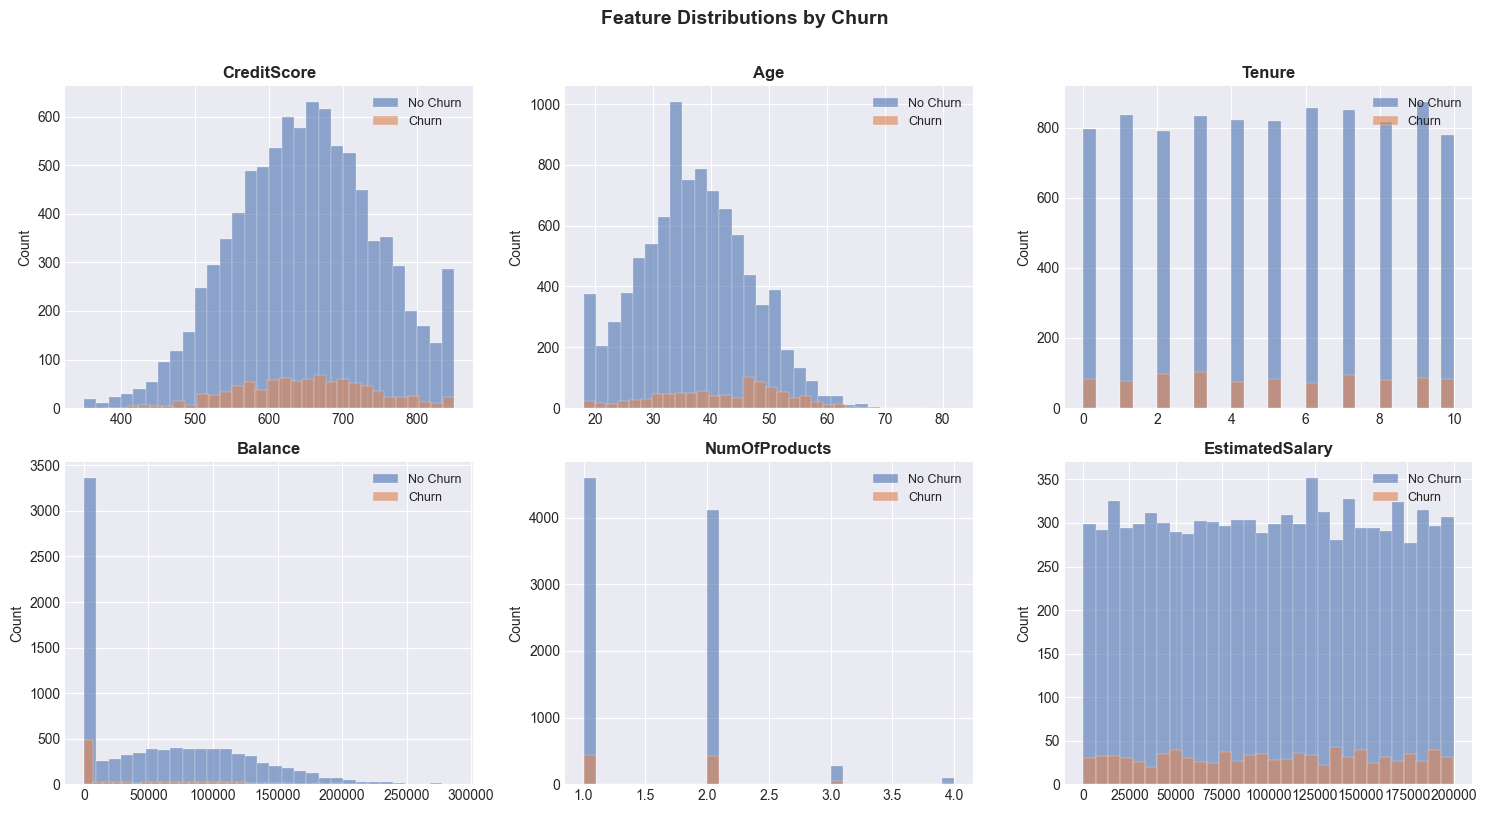

In [4]:
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color in zip([0, 1], pal):
        subset = df_raw[df_raw['Exited'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label='No Churn' if label == 0 else 'Churn',
                     edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Churn Rate by Categorical Features

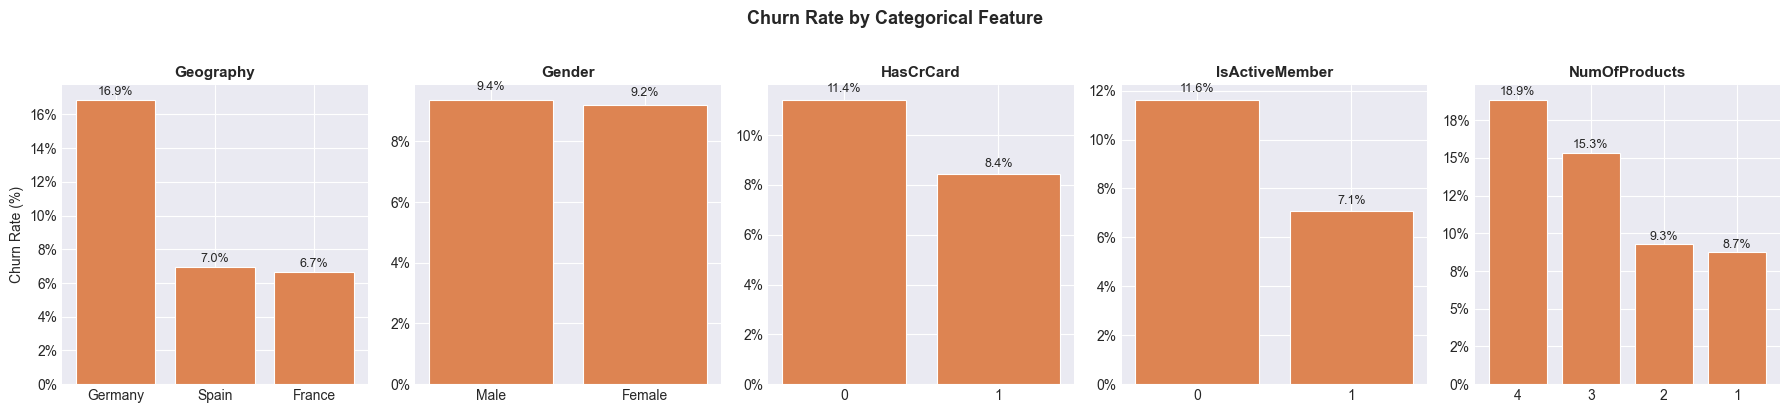

In [5]:
cat_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feat in enumerate(cat_features):
    churn_rate = df_raw.groupby(feat)['Exited'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values * 100,
                       color=pal[1], edgecolor='white', linewidth=0.8)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)' if i == 0 else '')
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%',
                     ha='center', fontsize=9)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

Checking multicollinearity between features — high correlation can hurt model interpretability.

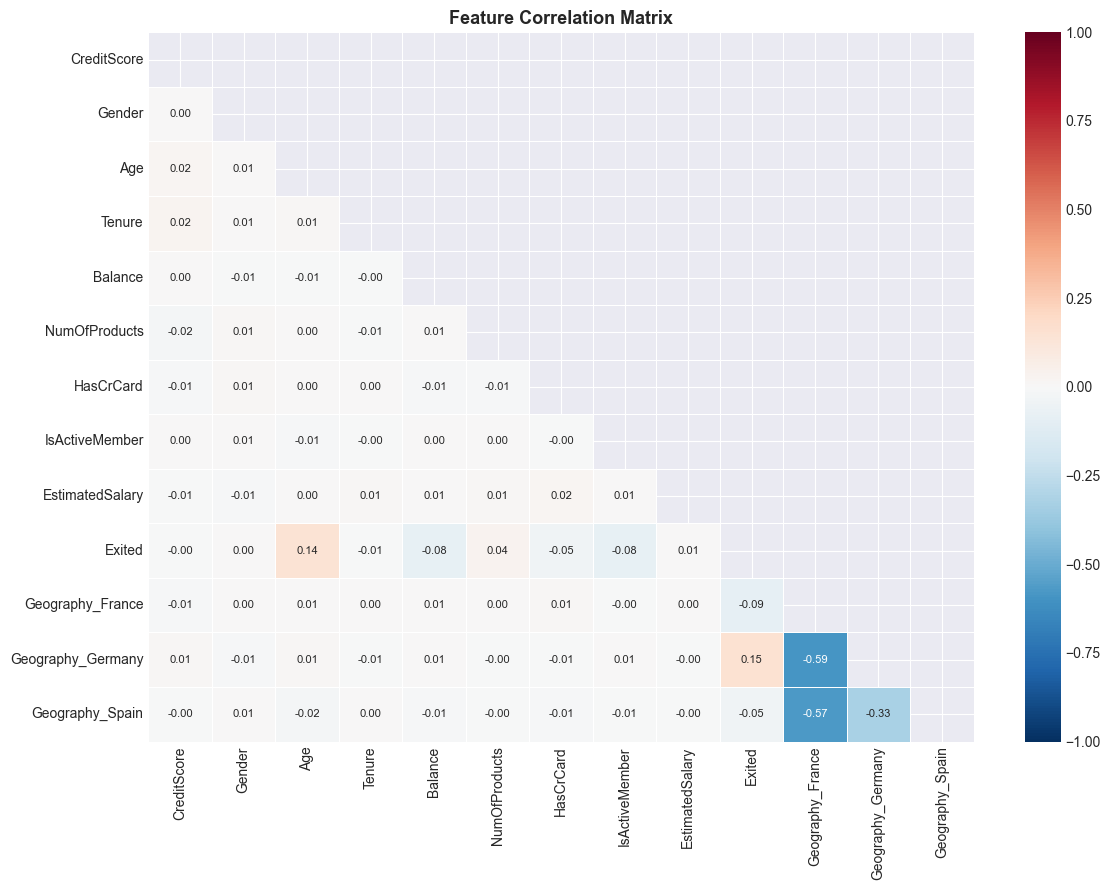

In [6]:
df_clean = clean_data(df_raw.copy())
df_enc = encode_features(df_clean.copy())

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

Quick Random Forest to rank features — validates our EDA intuitions.

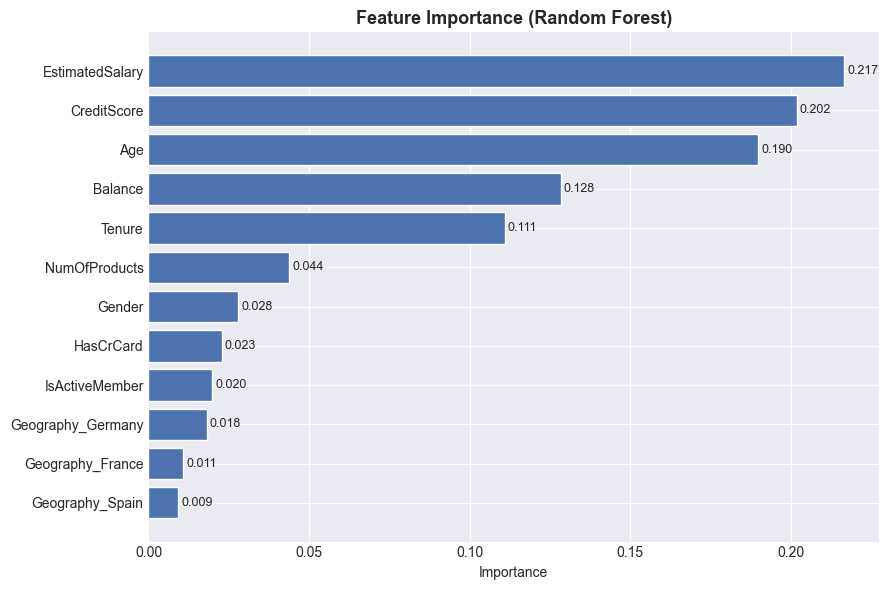

In [7]:
from sklearn.ensemble import RandomForestClassifier

X = df_enc.drop(columns=['Exited'])
y = df_enc['Exited']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color=pal[0], edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **Class imbalance**: ~9% churn rate → SMOTE applied during training
- **Age**: churned customers tend to be older — strongest signal
- **NumOfProducts**: customers with 3-4 products churn disproportionately
- **IsActiveMember**: inactive members churn significantly more
- **Geography**: Germany shows higher churn rate vs France/Spain
- **Balance**: customers with zero balance show different behavior
- **No strong multicollinearity** — all features kept